**Week 06: Dates**

In [2]:
#Libraries
import pandas as pd
#Load data
df = pd.read_csv("C:\ARCHIVOS\DOCUMENTS\Alvaro Universidad\M2 FIT\Practice\Sample - Superstore.csv",encoding = 'latin1')

<>:4: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
C:\Users\maryl\AppData\Local\Temp\ipykernel_30572\2291493658.py:4: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("C:\ARCHIVOS\DOCUMENTS\Alvaro Universidad\M2 FIT\Practice\Sample - Superstore.csv",encoding = 'latin1')


In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

**Exercise 1:Convert and extract**

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['month_name'] = df['Order Date'].dt.month_name()
df['weekday'] = df['Order Date'].dt.day_name()

#Shipping time
df['Shipping_days'] = (df['Ship Date']-df['Order Date']).dt.days
print(df['Shipping_days'].describe())

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping_days, dtype: float64


**Exercise 2:Monthly trend with resample()**

In [7]:
df_dated = df.set_index('Order Date')

monthly = df_dated['Sales'].resample('ME').sum().reset_index()
monthly.columns = ['month','Sales']

#Year-over-Year comparison
yearly = df_dated['Sales'].resample('YE').sum().reset_index()
yearly.columns = ['year','Sales']
yearly['yoy_pct'] = yearly['Sales'].pct_change()*100
print(yearly)

        year        Sales    yoy_pct
0 2014-12-31  484247.4981        NaN
1 2015-12-31  470532.5090  -2.832227
2 2016-12-31  609205.5980  29.471521
3 2017-12-31  733215.2552  20.355962


**Exercise 3:Plot the trend**

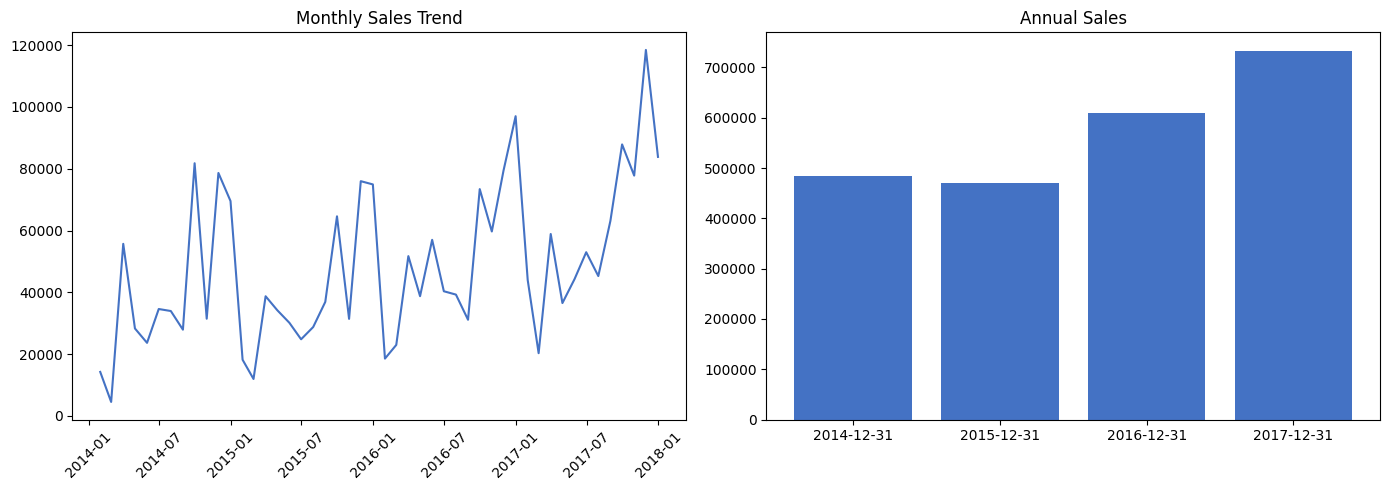

In [8]:
import matplotlib.pyplot as plt

fig,(ax1,ax2) = plt.subplots(1,2,figsize = (14,5))

ax1.plot(monthly['month'],monthly['Sales'],linewidth = 1.5,color ='#4472C4')
ax1.set_title('Monthly Sales Trend')
ax1.tick_params(axis='x',rotation = 45)

ax2.bar(yearly['year'].astype(str),yearly['Sales'],color ='#4472C4')
ax2.set_title('Annual Sales')

plt.tight_layout()
plt.savefig('sales_time.png',dpi=150)
plt.show()